# FER IMPLEMENTATION

## Import modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-06-29 11:24:23.530736: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-29 11:24:23.605668: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782725063.641659    9619 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782725063.653377    9619 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-29 11:24:23.728848: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Download dataset

In [2]:
path = '/kaggle/input/datasets/msambare/fer2013'

In [3]:
# Getting the path to the original train and test directories
train_dir = '/home/kamatsac/Desktop/Thesis/archive/train'
test_dir = '/home/kamatsac/Desktop/Thesis/archive/test'

## Class distribution

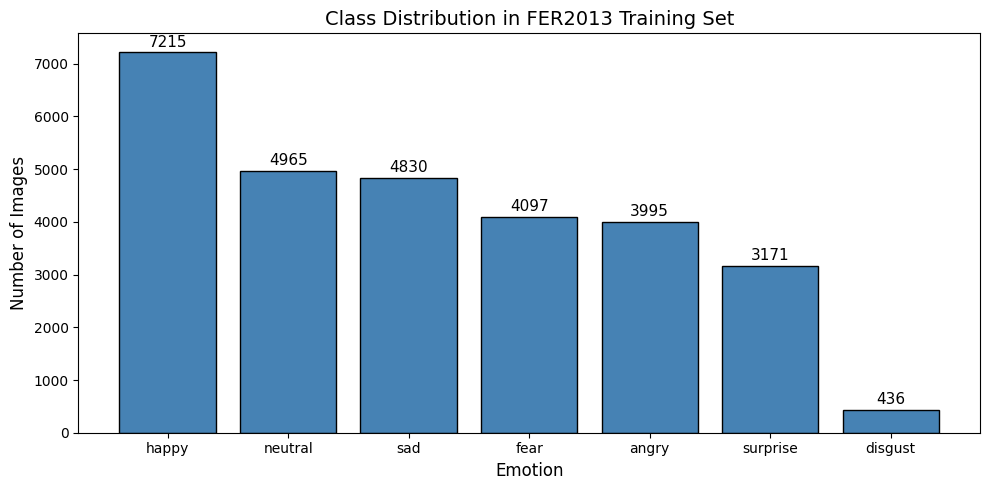

happy: 7215 images
neutral: 4965 images
sad: 4830 images
fear: 4097 images
angry: 3995 images
surprise: 3171 images
disgust: 436 images


In [4]:
import os
import matplotlib.pyplot as plt

# Get class names and count images in each
classes = os.listdir(train_dir)
class_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in classes}

# Sort by count
class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')

# Add count labels on top of each bar
for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', va='bottom', fontsize=11)

plt.title('Class Distribution in FER2013 Training Set', fontsize=14)
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.tight_layout()
plt.show()

# Print counts
for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

## Preprocessing

In [5]:
IMG_SIZE = (224, 224) #fer2013 has img size 48x48 so upscaling for resnet50 is required
BATCH_SIZE = 16

In [6]:
# Define preprocessing steps here

# train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
# val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
# test_datagen = ImageDataGenerator(rescale=1./255)
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input, validation_split=0.2)
val_datagen   = ImageDataGenerator(preprocessing_function=preprocess_input, validation_split=0.2)
test_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    subset='training',
    interpolation='bilinear',
    seed=42
)
validation_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    subset='validation',
    interpolation='bilinear',
    seed=42
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    interpolation='bilinear',
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


## Model Architecture

In [7]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import keras_tuner as kt

In [ ]:
# Define model architecture here

def build_model(hp):
    # Tunable hyperparameters
    dense_units = hp.Choice('dense_units', values=[128, 256, 512])
    dropout_rate = hp.Float('dropout_rate', min_value=0.3, max_value=0.6, step=0.1)
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4, 1e-5])
    l2_reg = hp.Choice('l2_reg', values=[0.0, 1e-5, 1e-4, 1e-3])

    num_classes = 7

    # Base model
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    # Build model
    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs)
    x = GlobalAveragePooling2D()(x)
    x = Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [9]:
# Build a sample model to inspect the architecture
import keras_tuner as kt
sample_hp = kt.HyperParameters()
sample_model = build_model(sample_hp)
sample_model.summary()

I0000 00:00:1782120452.378591      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782120452.384613      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,887 (90.98 MB)

 Trainable params: 263,175 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Hyperparameter Optimization

In [10]:
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_loss', # val accuracy before
    max_trials=30,
    executions_per_trial=1,    # Run each trial once to save compute
    directory='tuner_results_pretrained',
    project_name='emotion_recognition',
    overwrite=True             # Set False to resume if interrupted
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


### Search and get best parameters

In [12]:
tuner.search(
    train_generator,
    validation_data=validation_generator,
    epochs=8,           # Enough to compare trial quality without full training
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=False)]
)

# Get best hyperparameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print('Best hyperparameters:')
print(f"  Dense units:   {best_hp.get('dense_units')}")
print(f"  Dropout rate:  {best_hp.get('dropout_rate')}")
print(f"  Learning rate: {best_hp.get('learning_rate')}")
print(f"  L2 reg:        {best_hp.get('l2_reg')}")

# Build best model
best_model = tuner.hypermodel.build(best_hp)
best_model.save('best_model_hp.keras')
tuner.results_summary()

# After tuner.search() — save HPs explicitly
import json

best_hp_values = {
    'dense_units':   best_hp.get('dense_units'),
    'dropout_rate':  best_hp.get('dropout_rate'),
    'learning_rate': best_hp.get('learning_rate'),
    'l2_reg':        best_hp.get('l2_reg'),
}
with open('best_hp.json', 'w') as f:
    json.dump(best_hp_values, f)

Trial 30 Complete [00h 06m 19s]
val_loss: 1.2224397659301758

Best val_loss So Far: 1.1675246953964233
Total elapsed time: 02h 10m 03s
Best hyperparameters:
  Dense units:   256
  Dropout rate:  0.3
  Learning rate: 0.0001
  L2 reg:        1e-05
Results summary
Results in tuner_results_pretrained/emotion_recognition
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 28 summary
Hyperparameters:
dense_units: 256
dropout_rate: 0.3
learning_rate: 0.0001
l2_reg: 1e-05
Score: 1.1675246953964233

Trial 06 summary
Hyperparameters:
dense_units: 256
dropout_rate: 0.4
learning_rate: 0.0001
l2_reg: 0.0
Score: 1.1777102947235107

Trial 26 summary
Hyperparameters:
dense_units: 256
dropout_rate: 0.4
learning_rate: 0.0001
l2_reg: 1e-05
Score: 1.1784385442733765

Trial 17 summary
Hyperparameters:
dense_units: 128
dropout_rate: 0.3
learning_rate: 0.0001
l2_reg: 0.0001
Score: 1.2072957754135132

Trial 29 summary
Hyperparameters:
dense_units: 512
dropout_rate: 0.5
learning_rate: 0.0

## Load hyperparameters


In [13]:
import json
# Upload best_hp.json as a Kaggle dataset and update the path below
with open('/home/kamatsac/Desktop/Thesis/best_hp.json') as f:  # <-- update this path
    hp_values = json.load(f)

print('Loaded hyperparameters:')
print(f"  Dense units:   {hp_values['dense_units']}")
print(f"  Dropout rate:  {hp_values['dropout_rate']}")
print(f"  Learning rate: {hp_values['learning_rate']}")
print(f"  L2 regularization rate: {hp_values['l2_reg']}")

Loaded hyperparameters:
  Dense units:   256
  Dropout rate:  0.3
  Learning rate: 0.0001
  L2 regularization rate: 1e-05


In [15]:
# # Build best model
# best_model = load_model('/kaggle/input/datasets/childofblisss/baseline-output/best_model_hp.keras')

In [14]:
# Fix all HPs to baseline-tuned values — no tuner search runs here
hp = kt.HyperParameters()
hp.Fixed('dense_units',   hp_values['dense_units'])
hp.Fixed('dropout_rate',  hp_values['dropout_rate'])
hp.Fixed('learning_rate', hp_values['learning_rate'])
hp.Fixed('l2_reg', hp_values['l2_reg'])

best_model = build_model(hp)
best_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [16]:
# Define hyperparameters here

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    # monitor="val_accuracy",
    patience=10,               # Good for 60 epochs
    restore_best_weights=False,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,                # Triggers before early_stop, good balance
    min_lr=1e-6,
    verbose=1
)

## Model Training

In [17]:
# Train the model
history = best_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=60,                 
    callbacks=[checkpoint, early_stop, lr_scheduler]
)

Epoch 1/60
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3719 - loss: 1.6673
Epoch 1: val_accuracy improved from -inf to 0.48406, saving model to best_model.keras
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 56s 35ms/step - accuracy: 0.3720 - loss: 1.6672 - val_accuracy: 0.4841 - val_loss: 1.3670 - learning_rate: 1.0000e-04
Epoch 2/60
1435/1436 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4985 - loss: 1.3472
Epoch 2: val_accuracy improved from 0.48406 to 0.51907, saving model to best_model.keras
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - accuracy: 0.4985 - loss: 1.3472 - val_accuracy: 0.5191 - val_loss: 1.2947 - learning_rate: 1.0000e-04
Epoch 3/60
1434/1436 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5317 - loss: 1.2551
Epoch 3: val_accuracy improved from 0.51907 to 0.52935, saving model to best_model.keras
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - accuracy: 0.5317 - loss: 1.2551 - val_accuracy: 0.5294 - val_loss: 1.2552 - learning_rate: 1.0000e-04
Epoch 4/60
1434/1436 ━

### Save history

In [18]:
import pickle

# Save the history dict (not the Keras History object) for portability
with open('history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

### Read history

In [19]:
with open('/home/kamatsac/Desktop/Thesis/history.pkl', 'rb') as f:
    history_dict = pickle.load(f)

# Wrap in a simple namespace so existing plot code works unchanged
class _HistoryProxy:
    def __init__(self, d): self.history = d
history = _HistoryProxy(history_dict)

## Result visualization

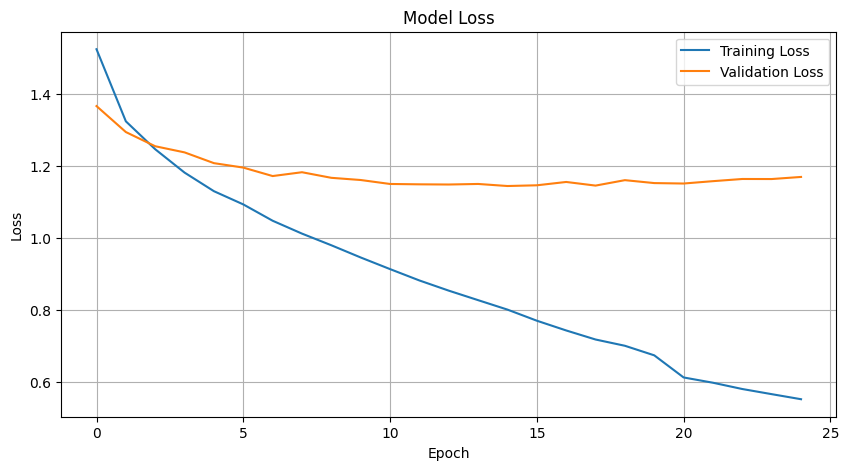

In [20]:
# Visualize the results
# Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

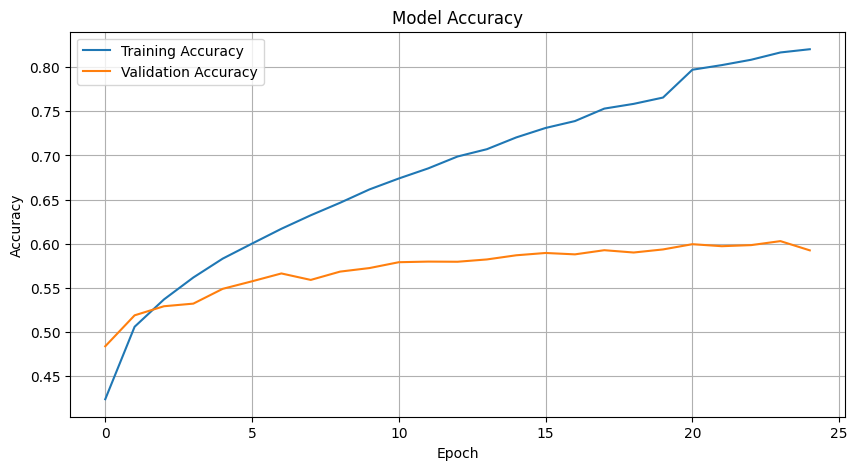

In [21]:
# Accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')   # Fixed: was incorrectly labelled 'Loss'
plt.legend()
plt.grid(True)
plt.show()

## Model Evaluation

### Load saved model

In [22]:
best_model = load_model('best_model.keras')

In [23]:
# Evaluate model on test data
loss, accuracy = best_model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


446/449 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5500 - loss: 1.2921

2026-06-29 13:50:08.505993: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1734_0', 8 bytes spill stores, 8 bytes spill loads



449/449 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.5505 - loss: 1.2908
Test Loss: 1.1524
Test Accuracy: 0.6006


In [24]:
predictions = best_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Optional: classification report
from sklearn.metrics import classification_report, f1_score
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

449/449 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step
              precision    recall  f1-score   support

       angry       0.51      0.48      0.49       958
     disgust       0.83      0.32      0.46       111
        fear       0.51      0.40      0.45      1024
       happy       0.70      0.85      0.76      1774
     neutral       0.53      0.62      0.58      1233
         sad       0.50      0.42      0.46      1247
    surprise       0.78      0.73      0.75       831

    accuracy                           0.60      7178
   macro avg       0.62      0.55      0.56      7178
weighted avg       0.59      0.60      0.59      7178



Macro F1 Score: 0.5645


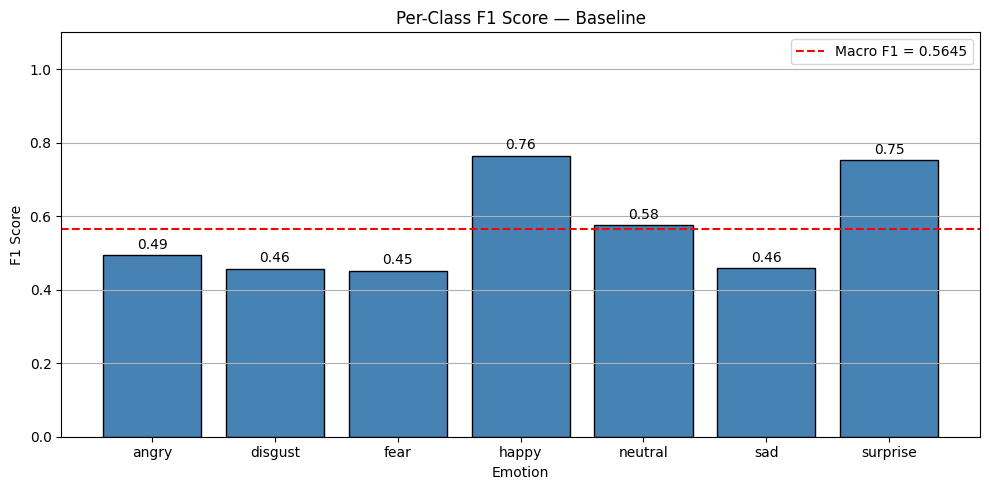

In [25]:
# Macro F1 — single number summary
macro_f1 = f1_score(true_classes, predicted_classes, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")

# Per-class F1 visualization
report = classification_report(true_classes, predicted_classes,
                                target_names=class_labels, output_dict=True)
per_class_f1 = [report[cls]['f1-score'] for cls in class_labels]

plt.figure(figsize=(10, 5))
bars = plt.bar(class_labels, per_class_f1, color='steelblue', edgecolor='black')
plt.axhline(y=macro_f1, color='red', linestyle='--', label=f'Macro F1 = {macro_f1:.4f}')
for bar, val in zip(bars, per_class_f1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10)
plt.title('Per-Class F1 Score — Baseline')
plt.xlabel('Emotion')
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

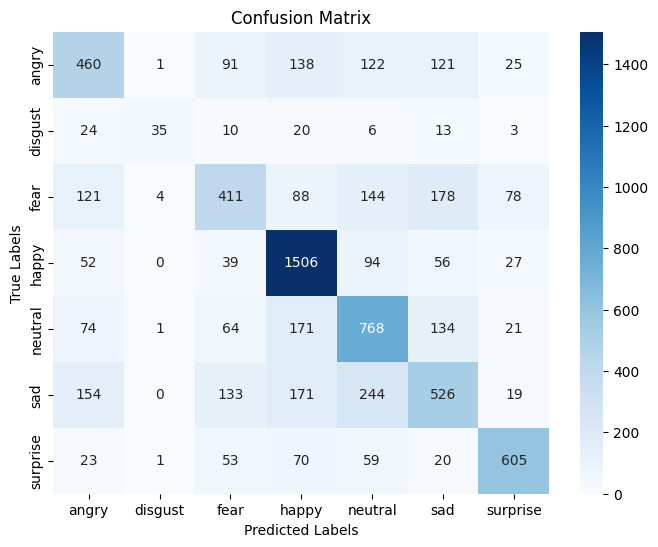

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()